# ***ANÁLISIS EXPLORATORIO***

# Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Primeras 5 columnas del df limpio


In [ ]:
df_clean.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares,mixed_type_col
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.7,-0.350000,-0.600,-3.400000,0.500000,-0.187500,0.000000,0.187500,593.0,494.0
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711.0,639.0
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500.0,494.0
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200.0,688.0
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505.0,579.0


# Gráfico de barras de conteo de artículos por canal

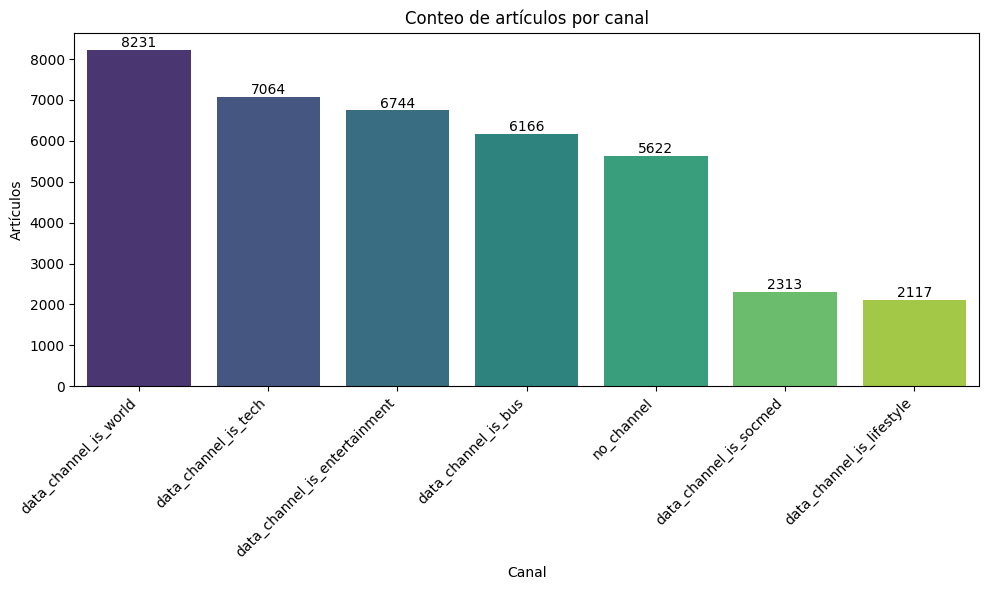

In [ ]:
channel_cols = ['data_channel_is_lifestyle', 'data_channel_is_entertainment', 'data_channel_is_bus',
                'data_channel_is_socmed', 'data_channel_is_tech', 'data_channel_is_world']

# Calcula los artículos por canal
channel_counts = df_clean[channel_cols].sum()

# Calcula los artículos que no tienen chanel
df_clean['no_channel'] = (df_clean[channel_cols].sum(axis=1) == 0).astype(int)
no_channel_count = df_clean['no_channel'].sum()

# Agrega el conteo de no_channel
channel_counts['no_channel'] = no_channel_count

# Convierte el conteo a df para graficar
channel_counts_df = channel_counts.reset_index()
channel_counts_df.columns = ['Channel', 'Count']
channel_counts_df = channel_counts_df.sort_values(by='Count', ascending=False)

# Grafica el conteo de artículos por canal
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Channel', y='Count', data=channel_counts_df, palette='viridis', hue='Channel', legend=False) # Assign x to hue and set legend=False
plt.title('Conteo de artículos por canal')
plt.xlabel('Canal')
plt.ylabel('Artículos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Agrega etiquetas de datos
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')


plt.show()

# Gráfico de barras de conteo de compartidos por canal

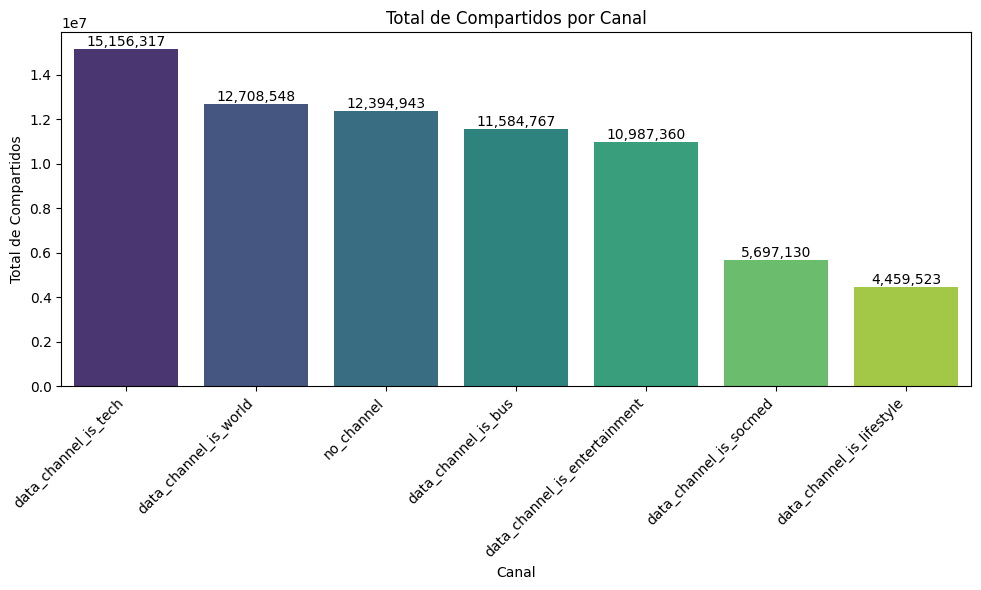

In [ ]:
# Calcular cantidad de artículos por canal
channel_shares = df_clean[channel_cols].multiply(df_clean['shares'], axis=0).sum()

# Calcular cantidad de artículos sin canal
df_clean['no_channel_flag'] = (df_clean[channel_cols].sum(axis=1) == 0).astype(int)
no_channel_shares = df_clean[df_clean['no_channel_flag'] == 1]['shares'].sum()

# Agregar conteo de artículos sin canal
channel_shares['no_channel'] = no_channel_shares

# Conversión a dataframe
channel_shares_df = channel_shares.reset_index()
channel_shares_df.columns = ['Channel', 'Total Shares']
channel_shares_df = channel_shares_df.sort_values(by='Total Shares', ascending=False)

# Graficar el conteo de artículos por canal
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Channel', y='Total Shares', data=channel_shares_df, palette='viridis', hue='Channel', legend=False)
plt.title('Total de Compartidos por Canal')
plt.xlabel('Canal')
plt.ylabel('Total de Compartidos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Agrega etiquetas de datos
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

# Gráfico de barras de conteo de artículos por día de la semana

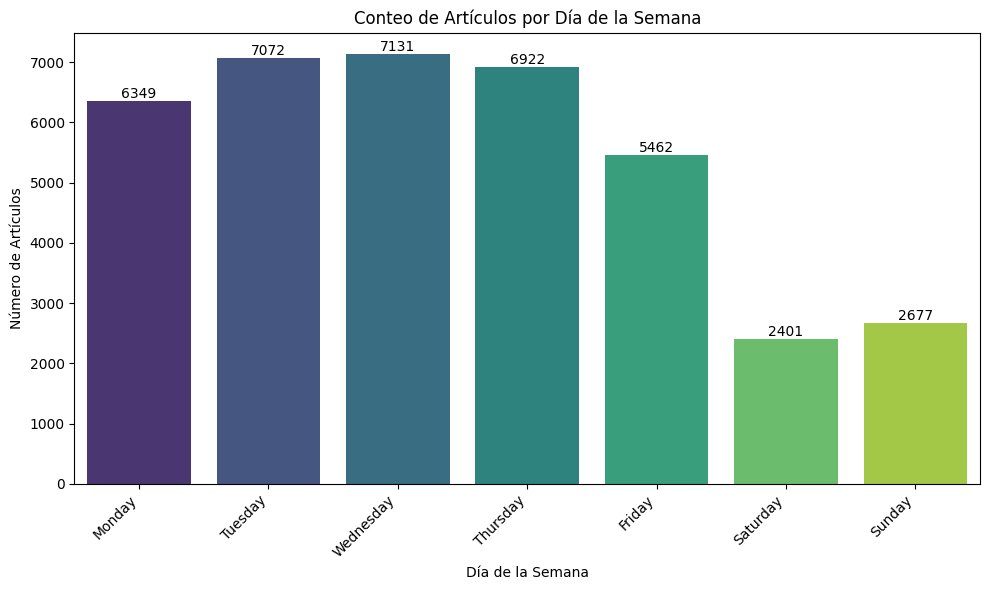

In [ ]:
# Obten los días de la semana
weekday_cols = ['weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday',
                'weekday_is_thursday', 'weekday_is_friday', 'weekday_is_saturday',
                'weekday_is_sunday']

# Cuenta los artículos pro día de la semana
weekday_counts = df_clean[weekday_cols].sum()

# Renombra columnas con los días de la semana
weekday_counts.index = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Grafica los artículos publicados por día de la semana
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=weekday_counts.index, y=weekday_counts.values, palette='viridis', hue=weekday_counts.index, legend=False) # Assign x to hue and set legend=False
plt.title('Conteo de Artículos por Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Número de Artículos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Añade etiqueta de datos
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

# Obten top 20 de artículos con más compartidos


In [ ]:
top_20_articles = df_clean.sort_values(by='shares', ascending=False).head(20)

print("Top 20 articles with the most shares:")
display(top_20_articles[['url', 'shares']])

Top 20 articles with the most shares:


,url,shares
17770,http://mashable.com/2013/12/18/seventeen-joins...,8300.0
33356,http://mashable.com/2014/09/24/blackberry-pass...,8300.0
29849,http://mashable.com/2014/07/29/leonardo-dicapr...,8300.0
6333,http://mashable.com/2013/05/03/modern-disney-p...,8300.0
14072,http://mashable.com/2013/10/04/silk-road-by-th...,8300.0
6407,http://mashable.com/2013/05/06/best-movie-soun...,8300.0
1754,http://mashable.com/2013/02/06/6-year-old-film/,8300.0
31169,http://mashable.com/2014/08/20/onbeep/,8300.0
3237,http://mashable.com/2013/03/05/breakfast-food-...,8300.0
11179,http://mashable.com/2013/08/08/monuments-men-t...,8300.0


# Diagrama de dispersión de num_imgs vs shares


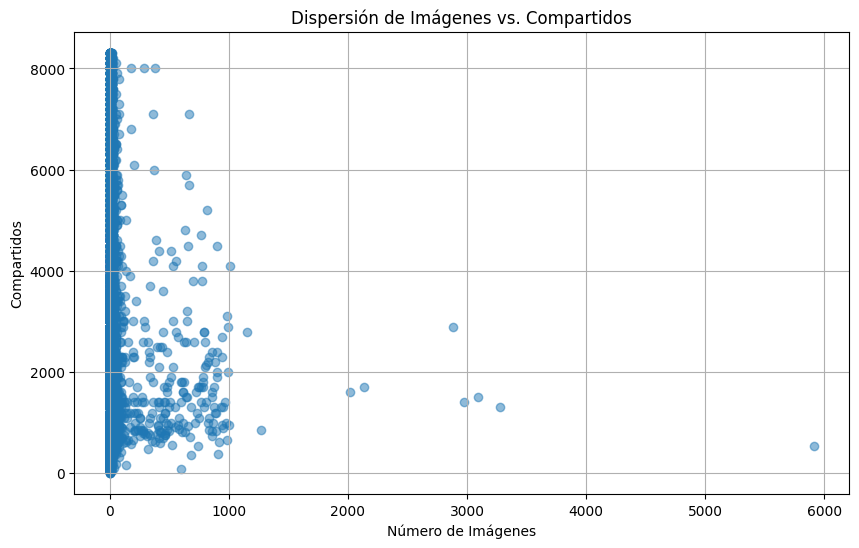

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['num_imgs'], df_clean['shares'], alpha=0.5)
plt.title('Dispersión de Imágenes vs. Compartidos')
plt.xlabel('Número de Imágenes')
plt.ylabel('Compartidos')
plt.grid(True)
plt.show()

# Diagrama de dispersión de num_videos vs shares


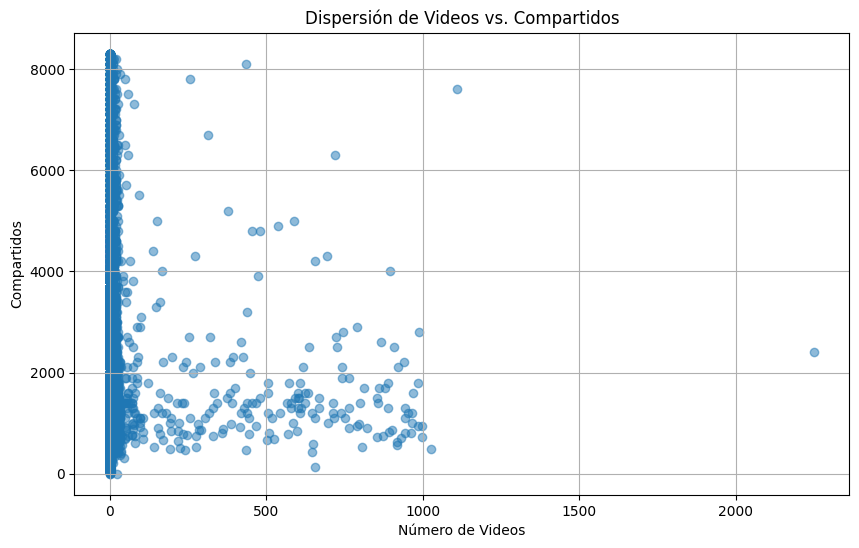

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['num_videos'], df_clean['shares'], alpha=0.5)
plt.title('Dispersión de Videos vs. Compartidos')
plt.xlabel('Número de Videos')
plt.ylabel('Compartidos')
plt.grid(True)
plt.show()

# Diagrama de dispersión de num_hrefs vs shares


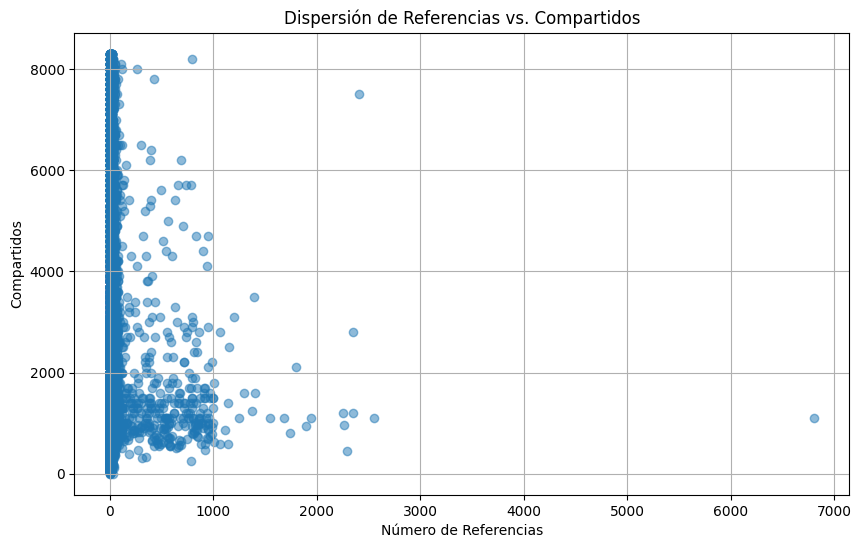

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['num_hrefs'], df_clean['shares'], alpha=0.5)
plt.title('Dispersión de Referencias vs. Compartidos')
plt.xlabel('Número de Referencias')
plt.ylabel('Compartidos')
plt.grid(True)
plt.show()

# Diagrama de dispersión de num_hrefs vs shares


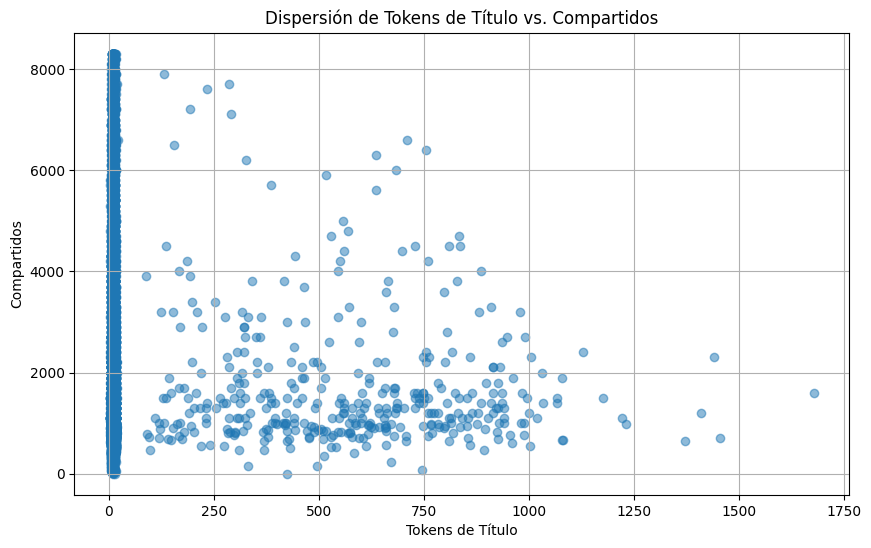

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['n_tokens_title'], df_clean['shares'], alpha=0.5)
plt.title('Dispersión de Tokens de Título vs. Compartidos')
plt.xlabel('Tokens de Título')
plt.ylabel('Compartidos')
plt.grid(True)
plt.show()

# Diagrama de dispersión de num_hrefs vs shares

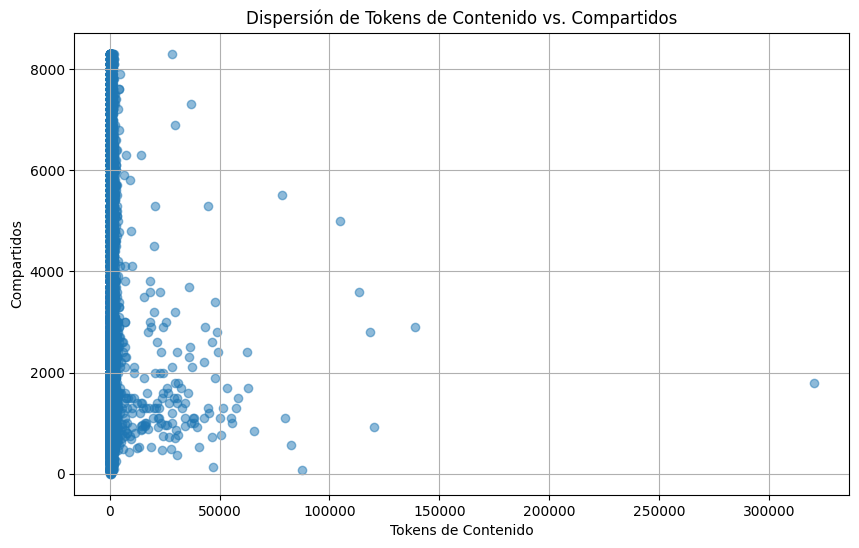

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['n_tokens_content'], df_clean['shares'], alpha=0.5)
plt.title('Dispersión de Tokens de Contenido vs. Compartidos')
plt.xlabel('Tokens de Contenido')
plt.ylabel('Compartidos')
plt.grid(True)
plt.show()

# Observamos las distribuciones de las variables

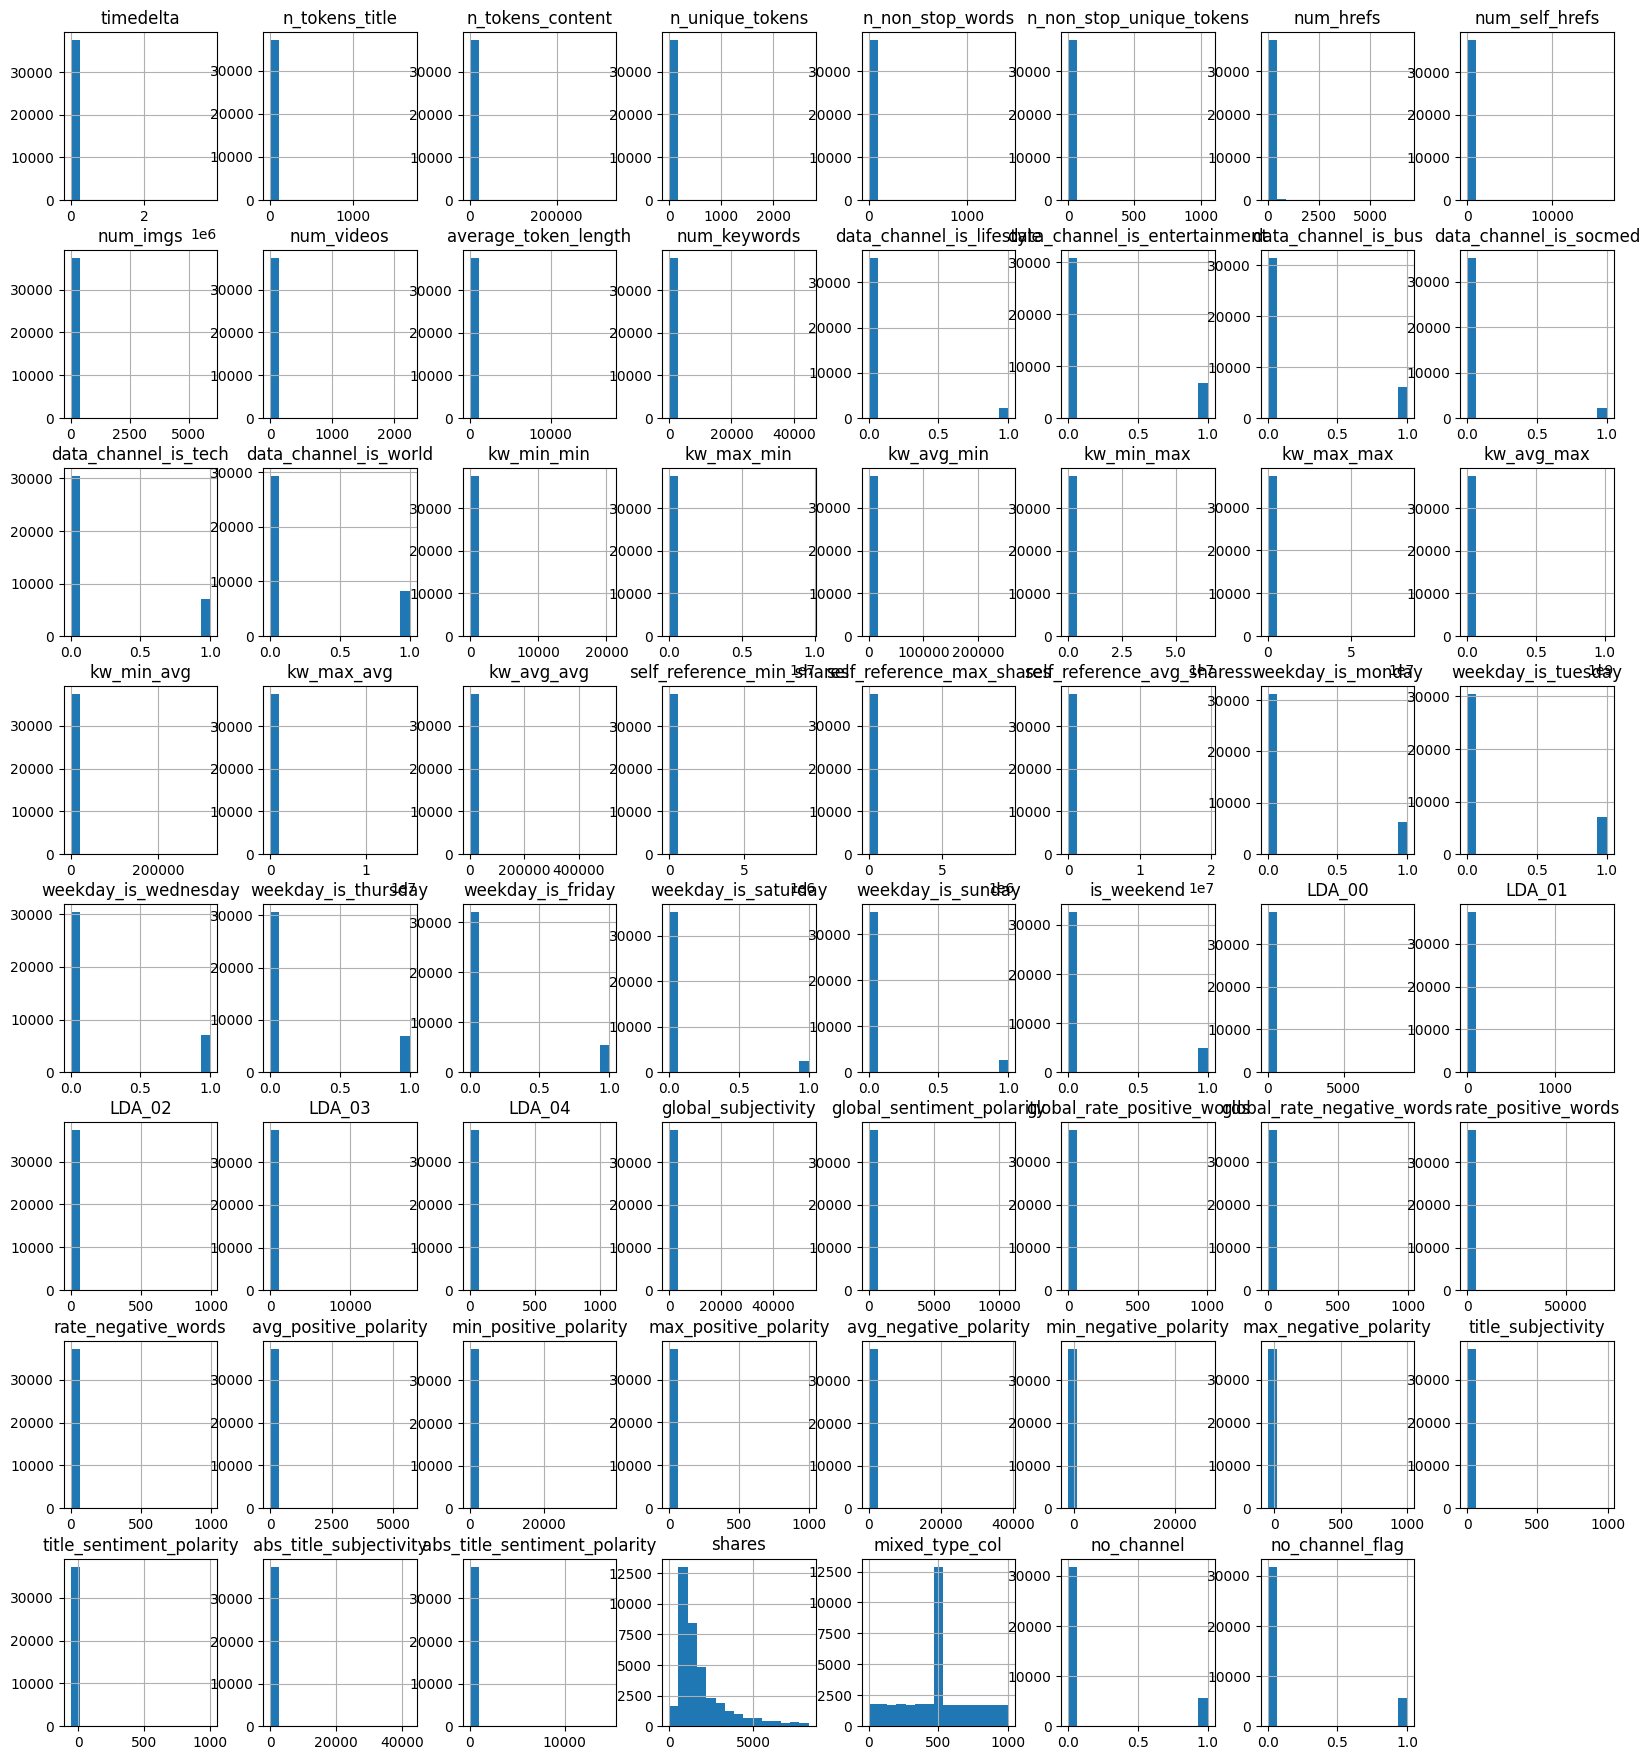

In [ ]:
df_clean.hist(bins=15, figsize=(20, 22))
plt.show()

# Generar un histograma de la columna 'shares'


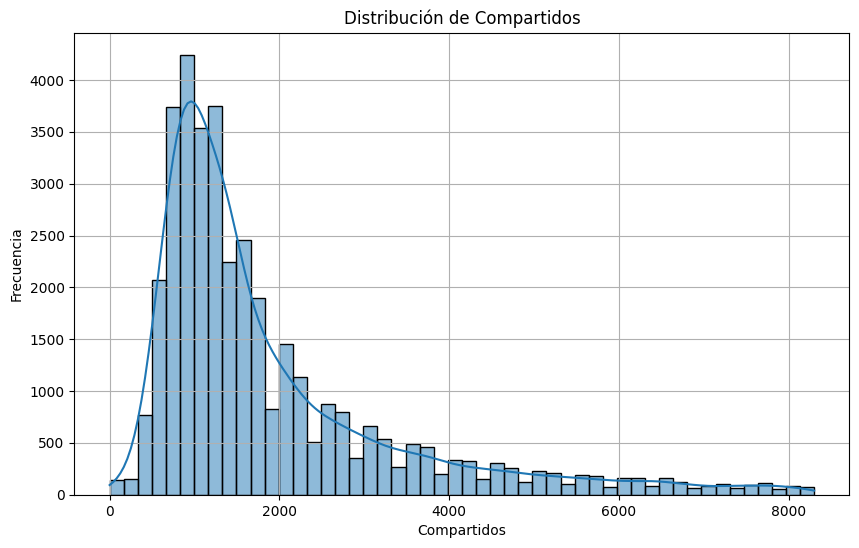

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['shares'], bins=50, kde=True)
plt.title('Distribución de Compartidos')
plt.xlabel('Compartidos')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()